In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

In [ ]:
location_info = {'ZLJQ' :{'country':'China', 'country_type':'adversary', 'name':'Jiuquan Space Launch Center', 'latitude':40.9580, 'longitude':100.2911},
                 '53564':{'country':'China', 'country_type':'adversary', 'name':'Taiyuan Satellite Launch Center', 'latitude':38.8491, 'longitude':111.6080},
                 '59855':{'country':'China', 'country_type':'adversary', 'name':'Wenchang Satellite Launch Center', 'latitude':19.6144, 'longitude':110.9511},
                 '56571':{'country':'China', 'country_type':'adversary', 'name':'Xichang Satellite Launch Center', 'latitude':28.2460, 'longitude':102.0265},
                 '35849':{'country':'Russia', 'country_type':'adversary', 'name':'Baikonur Cosmodrome', 'latitude':45.9650, 'longitude':63.305},
                 '22657':{'country':'Russia', 'country_type':'adversary', 'name':'Plesetsk Cosmodrome', 'latitude':62.9255, 'longitude':40.5777},
                 'KVBG':{'country':'United States', 'country_type':'friendly', 'name':'Vandenberg Space Force Base', 'latitude':34.7300, 'longitude':-120.5800},
                 'KXMR':{'country':'United States', 'country_type':'friendly', 'name':'Cape Canaveral Space Force Station', 'latitude':28.4700, 'longitude':-80.5500},
                }

In [112]:
def process_air_data(key):
    folder = 'data/raw/upper_air/'
    file = f'{key}_UA.csv'
    location_name = location_info[key]['name']
    country = location_info[key]['country']
    country_type = location_info[key]['country_type']
    latitude = location_info[key]['latitude']
    longitude = location_info[key]['longitude']

    
    date_range = pd.date_range(start='2004-01-01', end='2023-12-31')
    date_df = pd.DataFrame(np.array(date_range).T, columns=['DATE'])
    date_df['YEAR'] = date_df['DATE'].dt.year
    date_df['MONTH'] = date_df['DATE'].dt.month
    date_df['DAY'] = date_df['DATE'].dt.day
    date_df.drop(['DATE'], axis=1, inplace=True)

    
    bins = [0, 5000, 10000, 15000, 20000, 25000, 30000, np.inf]
    bin_names = ['0K_to_5K', '5K_to_10K', '10K_to_15K', '15K_to_20K', '20K_to_25K', '25K_to_30K', '30K_to_35K']
    
    dfs = []
    
    for name in bin_names:
        new_df = date_df.copy()
        new_df['HGT'] = name
        dfs.append(new_df)
    
    date_df = pd.concat(dfs).reset_index(drop=True)
    
    data = pd.read_csv(folder+file)

    if "DATETIME" in data.columns:
        to_keep = ['DATETIME', 'HGT', 'TEMP_AIR', 'WIND_LVL_DIR', 'WIND_LVL_SPD']
        data = data[to_keep]
        data['DATE'] = pd.to_datetime(data['DATETIME'], format='%m/%d/%Y', errors='coerce')
    else:
        to_keep = ['YYYYMMDDHHmmss', 'HGT', 'TEMP_AIR', 'WIND_LVL_DIR', 'WIND_LVL_SPD']
        data = data[to_keep]
        data['DATETIME'] = data['YYYYMMDDHHmmss']
        data.drop('YYYYMMDDHHmmss', axis=1, inplace=True)
        data['DATE'] = pd.to_datetime(data['DATETIME'], format='%Y-%m-%d %H:%M:%S', errors='coerce')


    data.loc[data['DATE'].isna(), 'DATE'] = pd.to_datetime(data.loc[data['DATE'].isna(), 'DATETIME'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
    data = data.loc[data['DATE'].notna()]
    
    data['YEAR'] = data['DATE'].dt.year
    data['MONTH'] = data['DATE'].dt.month
    data['DAY'] = data['DATE'].dt.day

    data['HGT_BIN'] = np.clip(data['HGT'], 0, 40000)
    data['HGT_BIN'] = pd.cut(data['HGT'], bins, labels=bin_names)
    
    data = data.loc[data['HGT_BIN'].notna()]

    data.drop(['DATETIME', 'DATE', 'HGT'], axis=1, inplace=True)

    data = data[['HGT_BIN','YEAR','MONTH','DAY','TEMP_AIR','WIND_LVL_DIR','WIND_LVL_SPD']]
    data.columns = ['HGT','YEAR','MONTH','DAY','TEMP','WIND_DIR','WIND_SPD']
    
    data = pd.merge(date_df, data, on=['HGT', 'YEAR', 'MONTH', 'DAY'], how='left')
    
    data = data.groupby(['HGT', 'YEAR', 'MONTH', 'DAY'], observed=True).mean()
    data = data.reset_index(drop=False)

    data = data.sort_values(['HGT', 'YEAR', 'MONTH', 'DAY']).reset_index(drop=True)
    
    for hgt in data['HGT'].unique():
        for col in ['TEMP','WIND_DIR','WIND_SPD']:
            data.loc[data['HGT']==hgt, col] = data.loc[data['HGT']==hgt, col].interpolate(method='linear')
            data.loc[data['HGT']==hgt, col] = data.loc[data['HGT']==hgt].groupby(['HGT', 'MONTH', 'DAY'], observed=True)[col].transform(lambda x: x.fillna(x.mean()))
    
    data = data.sort_values(['YEAR', 'MONTH', 'DAY', 'HGT']).reset_index(drop=True)

    table = data.pivot_table(data, index=['YEAR', 'MONTH', 'DAY'],
                       columns='HGT', aggfunc="mean")

    new_col_names = []
    col_names = table.columns.values
    for col_name in col_names:
        first = col_name[0]
        second = col_name[1]

        new_col_names.append(f'{first}_{second}')

    table.columns = new_col_names
    table = table.reset_index(drop=False)

    table['LOCATION_KEY'] = key
    table['NAME'] = location_name
    table['COUNTRY'] = country
    table['COUNTRY_TYPE'] = country_type
    table['LATITUDE'] = latitude
    table['LONGITUDE'] = longitude
    table['LAT_LON'] = table['LATITUDE'].astype(str) + ',' + table['LONGITUDE'].astype(str)
    
    col_order = ['LOCATION_KEY',
                 'NAME',
                 'COUNTRY',
                 'COUNTRY_TYPE',
                 'LATITUDE',
                 'LONGITUDE',
                 'LAT_LON',
                 'YEAR',
                 'MONTH',
                 'DAY',
                 'TEMP_0K_to_5K',
                 'TEMP_5K_to_10K',
                 'TEMP_10K_to_15K',
                 'TEMP_15K_to_20K',
                 'TEMP_20K_to_25K',
                 'TEMP_25K_to_30K',
                 'TEMP_30K_to_35K',
                 'WIND_DIR_0K_to_5K',
                 'WIND_DIR_5K_to_10K',
                 'WIND_DIR_10K_to_15K',
                 'WIND_DIR_15K_to_20K',
                 'WIND_DIR_20K_to_25K',
                 'WIND_DIR_25K_to_30K',
                 'WIND_DIR_30K_to_35K',
                 'WIND_SPD_0K_to_5K',
                 'WIND_SPD_5K_to_10K',
                 'WIND_SPD_10K_to_15K',
                 'WIND_SPD_15K_to_20K',
                 'WIND_SPD_20K_to_25K',
                 'WIND_SPD_25K_to_30K',
                 'WIND_SPD_30K_to_35K',]

    for col in col_order[10:]:
        if col not in table.columns:
            table[col] = np.nan

    table = table[col_order]

    return table


def process_surface_data(key):
    folder = 'data/raw/surface/'
    file = f'{key}_SFC.csv'
    name = location_info[key]['name']
    country = location_info[key]['country']
    country_type = location_info[key]['country_type']
    latitude = location_info[key]['latitude']
    longitude = location_info[key]['longitude']
    
    to_keep = ['OBSERVATIONTIME',
               'WINDDIRECTION',
               'WINDSPEED',
               'WINDGUSTSPEED',
               'VISIBILITY',
               'AIRTEMPERATURE',
               'PRECIPAMOUNT1',
               'PRECIPCONDITION1',
               'PRECIPAMOUNT2',
               'PRECIPCONDITION2',
               'PRECIPAMOUNT3',
               'PRECIPCONDITION3',
               'PRECIPAMOUNT4',
               'PRECIPCONDITION4',
               'PRESENTMANUAL1',
               'PRESENTMANUAL2',
               'PRESENTMANUAL3',
               'PRESENTMANUAL4',
               'PRESENTMANUAL5',
               'PRESENTMANUAL6',
               'PRESENTMANUAL7',
               'PRESENTAUTOMATED1',
               'PRESENTAUTOMATED2',
               'PRESENTAUTOMATED3',
               'CLOUDCEILING',
               'CLOUDCOVER',
               'CLOUDBASEHEIGHT',]
    
    
    date_range = pd.date_range(start='2004-01-01 00:00:00', end='2023-12-31 23:00:00', freq='1h')
    date_df = pd.DataFrame(np.array(date_range).T, columns=['DATE'])
    date_df['YEAR'] = date_df['DATE'].dt.year
    date_df['MONTH'] = date_df['DATE'].dt.month
    date_df['DAY'] = date_df['DATE'].dt.day
    date_df['HOUR'] = date_df['DATE'].dt.hour
    date_df.drop(['DATE'], axis=1, inplace=True)

    
    data = pd.read_csv(folder + file)
    data = data[to_keep]
    
    data['DATETIME'] = pd.to_datetime(data['OBSERVATIONTIME'], format='%Y-%m-%d %H:%M:%S')
    data['YEAR'] = data['DATETIME'].dt.year
    data['MONTH'] = data['DATETIME'].dt.month
    data['DAY'] = data['DATETIME'].dt.day
    data['HOUR'] = data['DATETIME'].dt.hour
    
    data = data.loc[data['YEAR'].notna()]

    wx_cond_cols = ['THUNDERSTORM', 'FREEZERAIN', 'PRCP']
    
    man_nums = [[13, 17, 18, 19, 29, 80, 81, 82, 83, 84, 85, 86, 87, 88, 91, 92, 93, 94, 95, 96, 97, 98, 99],
                [24, 27, 56, 57, 66, 67, 76, 77, 78, 79, 89, 90, 96, 99],
                [13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 27, 29, 36, 37, 38, 39, 50, 51, 52, 53, 54,
                 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78,
                 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99],]
    
    auto_nums = [[12, 18, 26, 90, 91, 92, 93, 94, 95, 96, 99],
                 [11, 25, 47, 48, 54, 55, 56, 64, 65, 66, 74, 75, 76, 77, 78, 89, 93, 96],
                 [11, 12, 18, 21, 22, 23, 24, 25, 26, 27, 40, 41, 42, 43, 44, 45, 46, 47, 48, 50, 51, 52, 53, 54,
                  55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 70, 71, 72, 73, 74, 75, 76, 77, 78, 80,
                  81, 82, 83, 84, 85, 86, 87, 89, 90, 91, 92, 93, 94, 95, 96],]

    for i in range(len(wx_cond_cols)):
        wx_cond = wx_cond_cols[i]
        man_num = man_nums[i]
        auto_num = auto_nums[i]

        data[wx_cond] = 0
        
        for x in range(1,8):
            col = f'PRESENTMANUAL{x}'
            data.loc[data[col].isin(man_num), wx_cond] = 1
    
        for x in range(1,4):
            col = f'PRESENTAUTOMATED{x}'
            data.loc[data[col].isin(auto_num), wx_cond] = 1



    data['CLOUDCOVER'].fillna(0, inplace=True)
    data['WINDSPEED'].fillna(0, inplace=True)
    data['WINDGUSTSPEED'].fillna(0, inplace=True)


    data['PRECIPAMOUNT1'].fillna(0, inplace=True)
    data['PRECIPAMOUNT'] = data['PRECIPAMOUNT1']

    data.loc[data['PRECIPAMOUNT'] > 0.01, 'PRCP'] = 1

    data['VISIBILITY'].fillna(70000, inplace=True)
    data['CLOUDBASEHEIGHT'].fillna(70000, inplace=True)
    data['CLOUDCEILING'].fillna(70000, inplace=True)

    data = data.drop(['OBSERVATIONTIME', 'DATETIME',
                      'PRESENTMANUAL1', 'PRESENTMANUAL2', 'PRESENTMANUAL3', 'PRESENTMANUAL4', 'PRESENTMANUAL5', 'PRESENTMANUAL6', 'PRESENTMANUAL7',
                      'PRESENTAUTOMATED1', 'PRESENTAUTOMATED2', 'PRESENTAUTOMATED3',
                      'PRECIPAMOUNT1', 'PRECIPAMOUNT2', 'PRECIPAMOUNT3', 'PRECIPAMOUNT4', 'PRECIPCONDITION1', 'PRECIPCONDITION2', 'PRECIPCONDITION3', 'PRECIPCONDITION4', ], axis=1)
    
    data = data.groupby(['YEAR', 'MONTH', 'DAY', 'HOUR']).agg({'WINDDIRECTION':'mean',
                                                               'WINDSPEED':'max',
                                                               'WINDGUSTSPEED':'max',
                                                               'VISIBILITY':'min',
                                                               'AIRTEMPERATURE':'mean',
                                                               'CLOUDCEILING':'min',
                                                               'CLOUDCOVER':'mean',
                                                               'CLOUDBASEHEIGHT':'min',
                                                               'THUNDERSTORM':'max',
                                                               'FREEZERAIN':'max',
                                                               'PRCP':'max',
                                                               'PRECIPAMOUNT':'max'})

    data = data.sort_values(['YEAR', 'MONTH', 'DAY', 'HOUR']).reset_index(drop=False)

    data = pd.merge(date_df, data, on=['YEAR', 'MONTH', 'DAY', 'HOUR'], how='left')

    to_fix = ['WINDDIRECTION',
            'WINDSPEED',
            'WINDGUSTSPEED',
            'VISIBILITY',
            'AIRTEMPERATURE',
            'THUNDERSTORM',
            'FREEZERAIN',
            'PRCP',]

    for col in to_fix:
        data[col] = data.groupby(['MONTH', 'DAY', 'HOUR'], observed=True)[col].transform(lambda x: x.fillna(x.mean()))
        data[col] = data.groupby(['MONTH', 'DAY'], observed=True)[col].transform(lambda x: x.fillna(x.mean()))
        
    
    data.loc[data['THUNDERSTORM'] >= .25, 'THUNDERSTORM'] = 1
    data.loc[data['THUNDERSTORM'] != 1, 'THUNDERSTORM'] = 0

    data.loc[data['FREEZERAIN'] >= .25, 'FREEZERAIN'] = 1
    data.loc[data['FREEZERAIN'] != 1, 'FREEZERAIN'] = 0

    data.loc[data['PRCP'] >= .25, 'PRCP'] = 1
    data.loc[data['PRCP'] != 1, 'PRCP'] = 0

    data.loc[(data['CLOUDCOVER'].isna()) & (data['PRCP']==1), 'CLOUDCOVER'] = 8
    data['CLOUDCOVER'] = data.groupby(['MONTH', 'DAY', 'HOUR'], observed=True)['CLOUDCOVER'].transform(lambda x: x.fillna(x.mean()))
    data['CLOUDCOVER'] = data.groupby(['YEAR', 'MONTH', 'DAY'], observed=True)['CLOUDCOVER'].transform(lambda x: x.fillna(x.mean()))
    data['CLOUDCOVER'].fillna(0, inplace=True)
    
    data.loc[(data['CLOUDCEILING'].isna()) & (data['PRCP']==1), 'CLOUDCEILING'] = data.loc[(data['CLOUDCEILING'].isna()) & (data['PRCP']==1)].groupby(['MONTH', 'PRCP'], observed=True)['CLOUDCEILING'].transform(lambda x: x.fillna(x.mean()))
    data['CLOUDCEILING'] = data.groupby(['MONTH', 'DAY', 'HOUR'], observed=True)['CLOUDCEILING'].transform(lambda x: x.fillna(x.mean()))
    data['CLOUDCEILING'] = data.groupby(['YEAR', 'MONTH', 'DAY'], observed=True)['CLOUDCEILING'].transform(lambda x: x.fillna(x.mean()))
    data['CLOUDCEILING'].fillna(70000, inplace=True)
    
    data.loc[(data['CLOUDBASEHEIGHT'].isna()) & (data['PRCP']==1), 'CLOUDBASEHEIGHT'] = data.loc[(data['CLOUDBASEHEIGHT'].isna()) & (data['PRCP']==1)].groupby(['MONTH', 'PRCP'], observed=True)['CLOUDBASEHEIGHT'].transform(lambda x: x.fillna(x.mean()))
    data['CLOUDBASEHEIGHT'] = data.groupby(['MONTH', 'DAY', 'HOUR'], observed=True)['CLOUDBASEHEIGHT'].transform(lambda x: x.fillna(x.mean()))
    data['CLOUDBASEHEIGHT'] = data.groupby(['YEAR', 'MONTH', 'DAY'], observed=True)['CLOUDBASEHEIGHT'].transform(lambda x: x.fillna(x.mean()))
    data['CLOUDBASEHEIGHT'].fillna(70000, inplace=True)
    
    data.loc[(data['PRECIPAMOUNT'].isna()) & (data['PRCP']==1), 'PRECIPAMOUNT'] = data.loc[(data['PRECIPAMOUNT'].isna()) & (data['PRCP']==1)].groupby(['MONTH', 'PRCP'], observed=True)['PRECIPAMOUNT'].transform(lambda x: x.fillna(x.mean()))
    data['PRECIPAMOUNT'] = data.groupby(['MONTH', 'DAY', 'HOUR'], observed=True)['PRECIPAMOUNT'].transform(lambda x: x.fillna(x.mean()))
    data['PRECIPAMOUNT'] = data.groupby(['YEAR', 'MONTH', 'DAY'], observed=True)['PRECIPAMOUNT'].transform(lambda x: x.fillna(x.mean()))
    data['PRECIPAMOUNT'].fillna(0, inplace=True)

    data.loc[(data['PRCP']==1), 'CLOUDCOVER'] = 8
    data.loc[(data['PRCP']==1), 'CLOUDCEILING'] = np.clip(data.loc[(data['PRCP']==1), 'CLOUDCEILING'], 0, 30000)
    data.loc[(data['PRCP']==1), 'CLOUDBASEHEIGHT'] = np.clip(data.loc[(data['PRCP']==1), 'CLOUDBASEHEIGHT'], 0, 30000)

    data['CLOUDCOND'] = 'CLR'
    data.loc[(data['CLOUDCOVER'] >= 1) & (data['CLOUDCOVER'] <= 2), 'CLOUDCOND'] = 'FEW'
    data.loc[(data['CLOUDCOVER'] >= 3) & (data['CLOUDCOVER'] <= 4), 'CLOUDCOND'] = 'SCT'
    data.loc[(data['CLOUDCOVER'] >= 5) & (data['CLOUDCOVER'] <= 7), 'CLOUDCOND'] = 'BKN'
    data.loc[(data['CLOUDCOVER'] >= 8), 'CLOUDCOND'] = 'OVC'

    data.loc[data['CLOUDCOND'].isin(['BKN','OVC']), 'CLOUDCEILING'] = np.clip(data.loc[data['CLOUDCOND'].isin(['BKN','OVC']), 'CLOUDCEILING'], 0, 40000)
    data.loc[data['CLOUDCOND'].isin(['BKN','OVC']), 'CLOUDBASEHEIGHT'] = np.clip(data.loc[data['CLOUDCOND'].isin(['BKN','OVC']), 'CLOUDBASEHEIGHT'], 0, 40000)

    data['LOCATION_KEY'] = key
    data['NAME'] = name
    data['COUNTRY'] = country
    data['COUNTRY_TYPE'] = country_type
    data['LATITUDE'] = latitude
    data['LONGITUDE'] = longitude
    data['LAT_LON'] = data['LATITUDE'].astype(str) + ',' + data['LONGITUDE'].astype(str)
    
    data['WEATHER_KEY'] = data['LOCATION_KEY'] + '_' + data['YEAR'].astype(str) + '_' + data['MONTH'].astype(str) + '_' + data['DAY'].astype(str) + '_' + data['HOUR'].astype(str)

    col_order = ['WEATHER_KEY',
                 'LOCATION_KEY',
                 'NAME',
                 'COUNTRY',
                 'COUNTRY_TYPE',
                 'LATITUDE',
                 'LONGITUDE',
                 'LAT_LON',
                 'YEAR',
                 'MONTH',
                 'DAY',
                 'HOUR',
                 'WINDDIRECTION',
                 'WINDSPEED',
                 'WINDGUSTSPEED',
                 'VISIBILITY',
                 'AIRTEMPERATURE',
                 'CLOUDCEILING',
                 'CLOUDCOVER',
                 'CLOUDBASEHEIGHT',
                 'CLOUDCOND',
                 'THUNDERSTORM',
                 'FREEZERAIN',
                 'PRCP',
                 'PRECIPAMOUNT',]

    data = data[col_order]

    return data

def calculate_upper_air_conditions(data):
    wind_cols = ['0K_to_5K', '5K_to_10K', '10K_to_15K', '15K_to_20K', '20K_to_25K', '25K_to_30K', '30K_to_35K']
    
    for y in range(len(wind_cols)-1):
        top_col = wind_cols[y+1]
        bottom_col = wind_cols[y]
    
        mag_top = data['WIND_SPD_'+top_col]
        mag_bottom = data['WIND_SPD_'+bottom_col]
    
        angle_top = np.radians(data['WIND_DIR_'+top_col])
        angle_bottom = np.radians(data['WIND_DIR_'+bottom_col])
        
        wind_top_x = mag_top * np.cos(angle_top)
        wind_top_y = mag_top * np.sin(angle_top)
    
        wind_bottom_x = mag_bottom * np.cos(angle_bottom)
        wind_bottom_y = mag_bottom * np.sin(angle_bottom)
    
        change_x = wind_top_x - wind_bottom_x
        change_y = wind_top_y - wind_bottom_y
    
        shear = np.sqrt(change_x**2 + change_y**2)
    
        data['WIND_SHEAR_'+top_col] = shear
    
    
    data['FULL_CLOUD_COVER'] = 0
    data.loc[data['CLOUDCOND'].isin(['BKN', 'OVC']), 'FULL_CLOUD_COVER'] = 1
    
    bins = [0, 5000, 10000, 15000, 20000, 25000, 30000, np.inf]
    bin_names = ['0K_to_5K', '5K_to_10K', '10K_to_15K', '15K_to_20K', '20K_to_25K', '25K_to_30K', '30K_to_35K']
    
    data['CLOUD_HEIGHT'] = pd.cut(data['CLOUDCEILING'], bins, labels=bin_names)
    data['CLOUD_HEIGHT'].fillna('30K_to_35K', inplace=True)
    
    values = []
    
    heights = data.loc[data['CLOUD_HEIGHT'].notna(), 'CLOUD_HEIGHT'].values
    indexes = data.loc[data['CLOUD_HEIGHT'].notna(), 'CLOUD_HEIGHT'].index.values
    
    data['CEILINGTEMP'] = np.nan
    for idx, height in zip(indexes, heights):
        data.loc[idx, 'CEILINGTEMP'] = data.loc[idx, 'TEMP_'+height]

    data['CEILINGTEMP'].fillna(20, inplace=True)
    
    return data

In [113]:
all_upper_air = []

for key in list(location_info.keys()):
    upper_air_data = process_air_data(key)
    surface_data = process_surface_data(key)
    
    combined_data = pd.merge(surface_data, upper_air_data, on=['LOCATION_KEY', 'NAME', 'COUNTRY', 'COUNTRY_TYPE', 'LATITUDE', 'LONGITUDE', 'LAT_LON', 'YEAR', 'MONTH', 'DAY']).sort_values(['YEAR', 'MONTH', 'DAY', 'HOUR']).reset_index(drop=True)
    combined_data = calculate_upper_air_conditions(combined_data)

    print(location_info[key]['name'])
    #display(combined_data)
    #print(key, combined_data.isna().any().sum())
    display(combined_data.isna().mean())
    print('-'*150)
    
    combined_data.to_csv(f'data/preprocessed/{key}_weather_2.csv', index=False)
    all_upper_air.append(combined_data)

all_upper_air = pd.concat(all_upper_air).sort_values(['LOCATION_KEY', 'YEAR', 'MONTH', 'DAY', 'HOUR']).reset_index(drop=True)
all_upper_air.to_csv('data/combined_weather_data_2.csv', index=False)


C:\Users\aj100\AppData\Local\Temp\ipykernel_9688\1604660775.py:248: DtypeWarning: Columns (12,13,27,183,185,186) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(folder + file)


Jiuquan Space Launch Center


WEATHER_KEY            0.0
LOCATION_KEY           0.0
NAME                   0.0
COUNTRY                0.0
COUNTRY_TYPE           0.0
LATITUDE               0.0
LONGITUDE              0.0
LAT_LON                0.0
YEAR                   0.0
MONTH                  0.0
DAY                    0.0
HOUR                   0.0
WINDDIRECTION          0.0
WINDSPEED              0.0
WINDGUSTSPEED          0.0
VISIBILITY             0.0
AIRTEMPERATURE         0.0
CLOUDCEILING           0.0
CLOUDCOVER             0.0
CLOUDBASEHEIGHT        0.0
CLOUDCOND              0.0
THUNDERSTORM           0.0
FREEZERAIN             0.0
PRCP                   0.0
PRECIPAMOUNT           0.0
TEMP_0K_to_5K          0.0
TEMP_5K_to_10K         0.0
TEMP_10K_to_15K        0.0
TEMP_15K_to_20K        0.0
TEMP_20K_to_25K        0.0
TEMP_25K_to_30K        0.0
TEMP_30K_to_35K        0.0
WIND_DIR_0K_to_5K      0.0
WIND_DIR_5K_to_10K     0.0
WIND_DIR_10K_to_15K    0.0
WIND_DIR_15K_to_20K    0.0
WIND_DIR_20K_to_25K    0.0
W

------------------------------------------------------------------------------------------------------------------------------------------------------


C:\Users\aj100\AppData\Local\Temp\ipykernel_9688\1604660775.py:248: DtypeWarning: Columns (13,27,185,186) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(folder + file)


...

------------------------------------------------------------------------------------------------------------------------------------------------------


C:\Users\aj100\AppData\Local\Temp\ipykernel_9688\1604660775.py:248: DtypeWarning: Columns (12,13,27,143,185,186) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(folder + file)


Cape Canaveral Space Force Station


WEATHER_KEY            0.0
LOCATION_KEY           0.0
NAME                   0.0
COUNTRY                0.0
COUNTRY_TYPE           0.0
LATITUDE               0.0
LONGITUDE              0.0
LAT_LON                0.0
YEAR                   0.0
MONTH                  0.0
DAY                    0.0
HOUR                   0.0
WINDDIRECTION          0.0
WINDSPEED              0.0
WINDGUSTSPEED          0.0
VISIBILITY             0.0
AIRTEMPERATURE         0.0
CLOUDCEILING           0.0
CLOUDCOVER             0.0
CLOUDBASEHEIGHT        0.0
CLOUDCOND              0.0
THUNDERSTORM           0.0
FREEZERAIN             0.0
PRCP                   0.0
PRECIPAMOUNT           0.0
TEMP_0K_to_5K          0.0
TEMP_5K_to_10K         0.0
TEMP_10K_to_15K        0.0
TEMP_15K_to_20K        0.0
TEMP_20K_to_25K        0.0
TEMP_25K_to_30K        0.0
TEMP_30K_to_35K        0.0
WIND_DIR_0K_to_5K      0.0
WIND_DIR_5K_to_10K     0.0
WIND_DIR_10K_to_15K    0.0
WIND_DIR_15K_to_20K    0.0
WIND_DIR_20K_to_25K    0.0
W

------------------------------------------------------------------------------------------------------------------------------------------------------


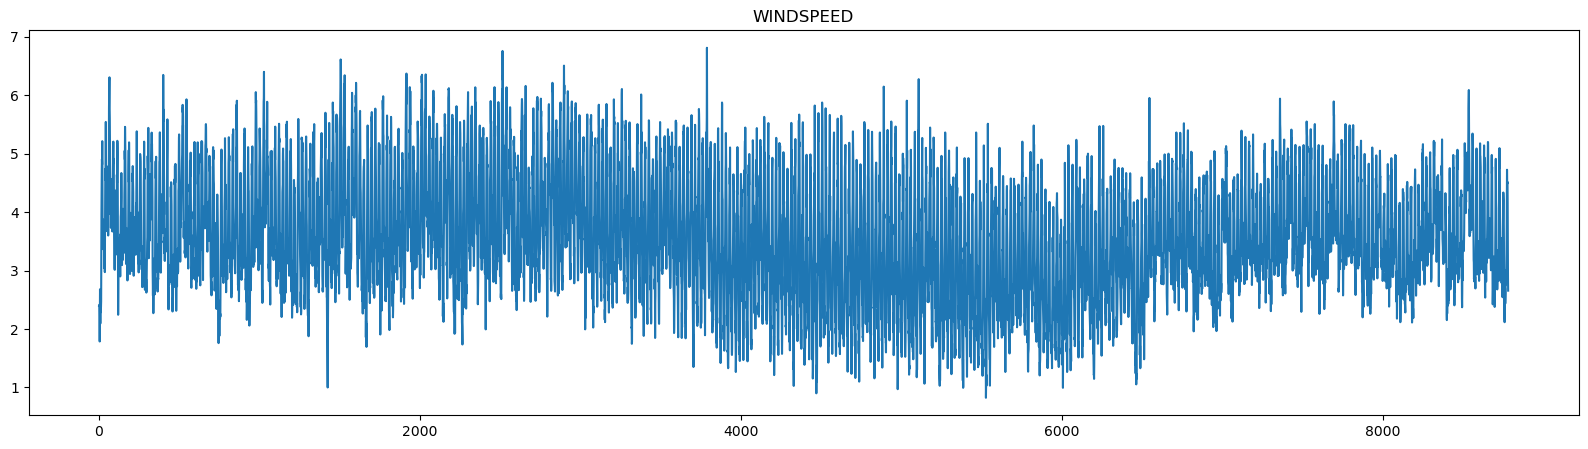

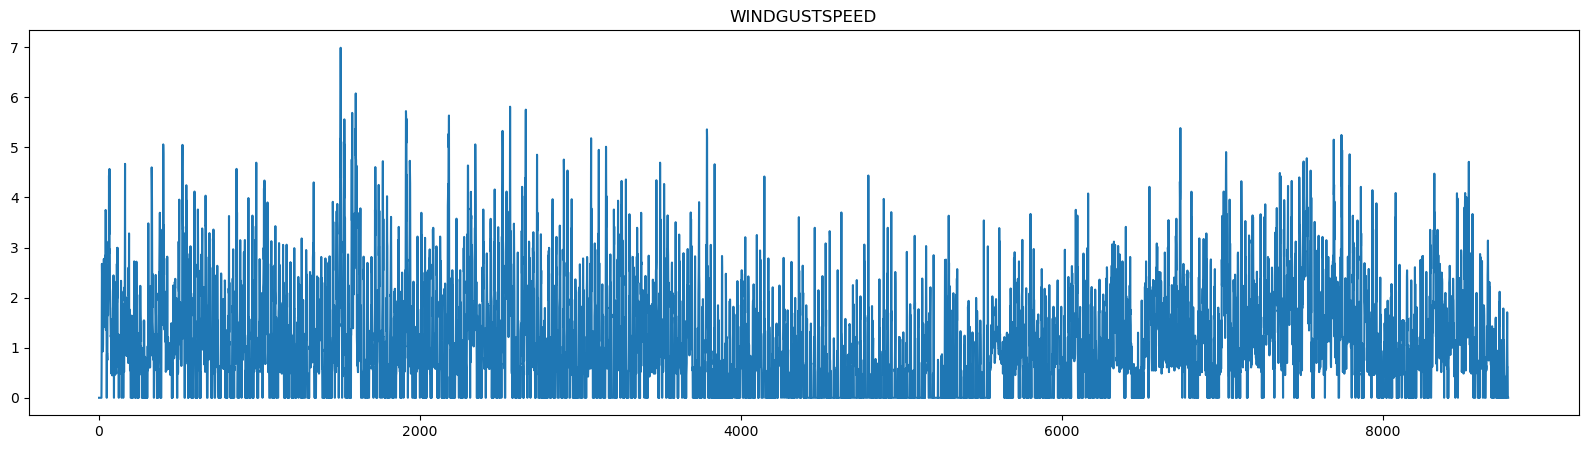

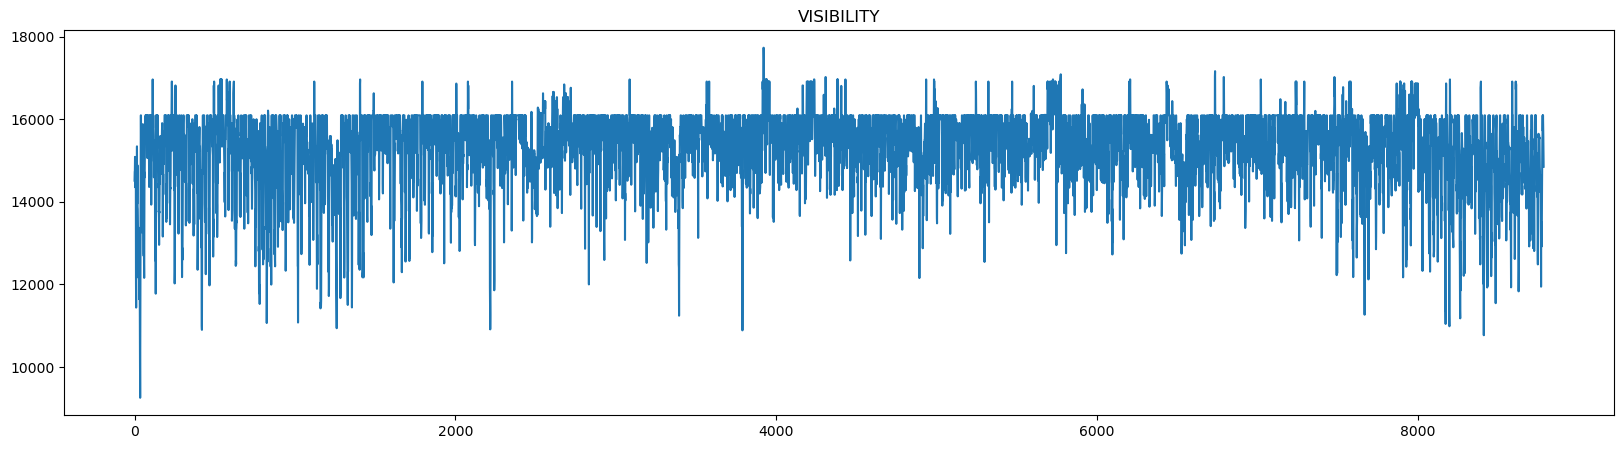

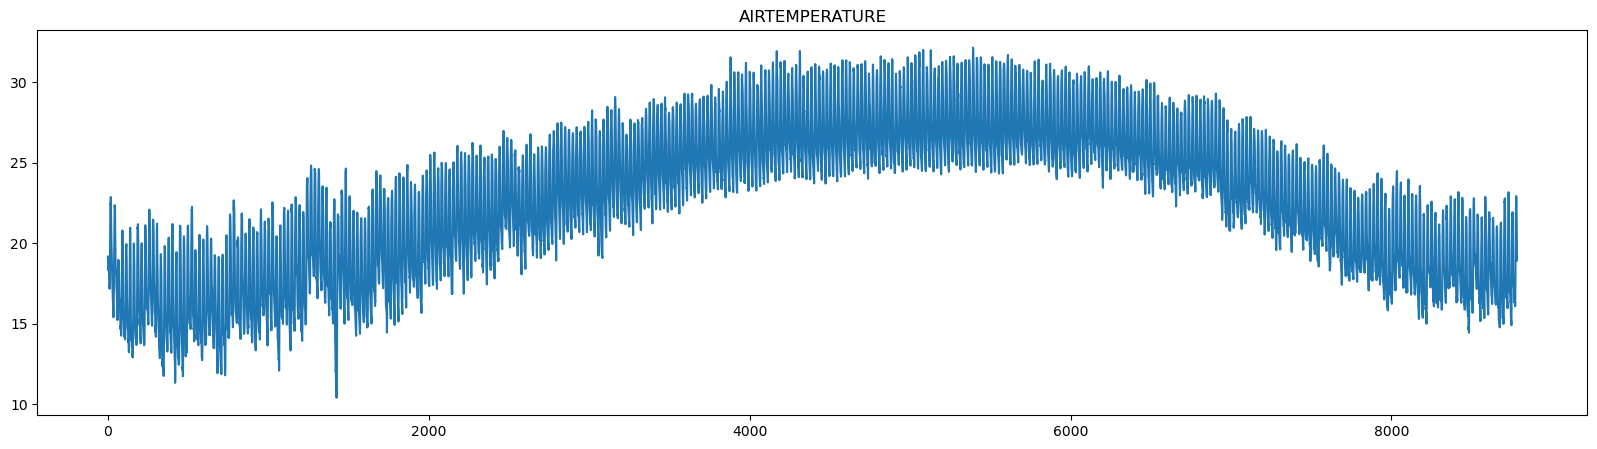

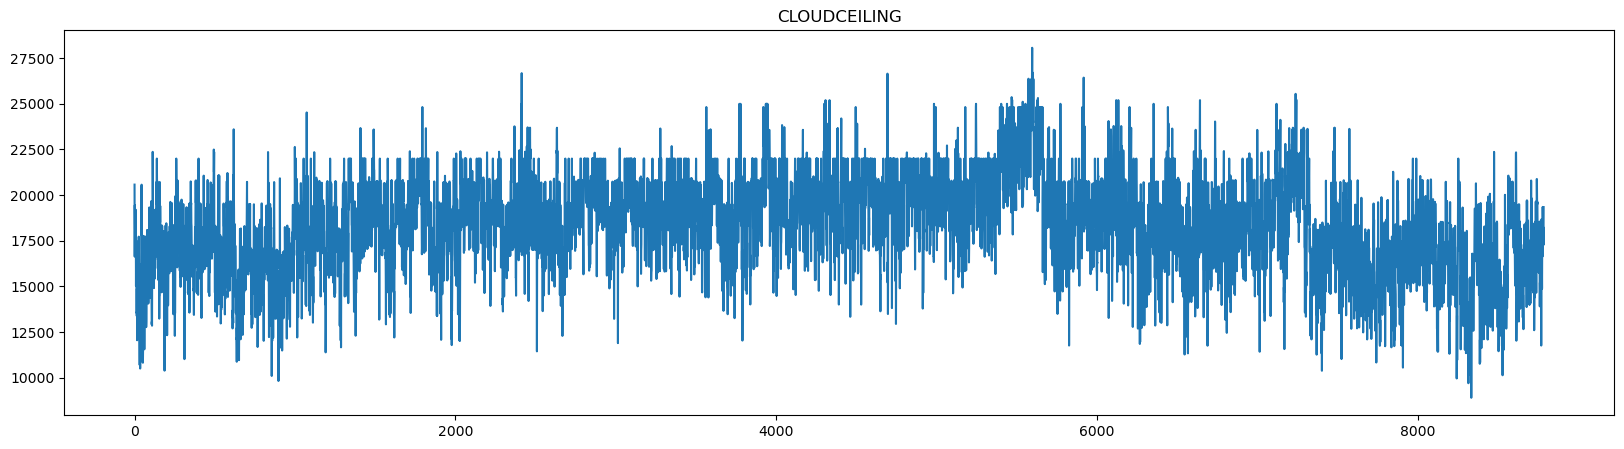

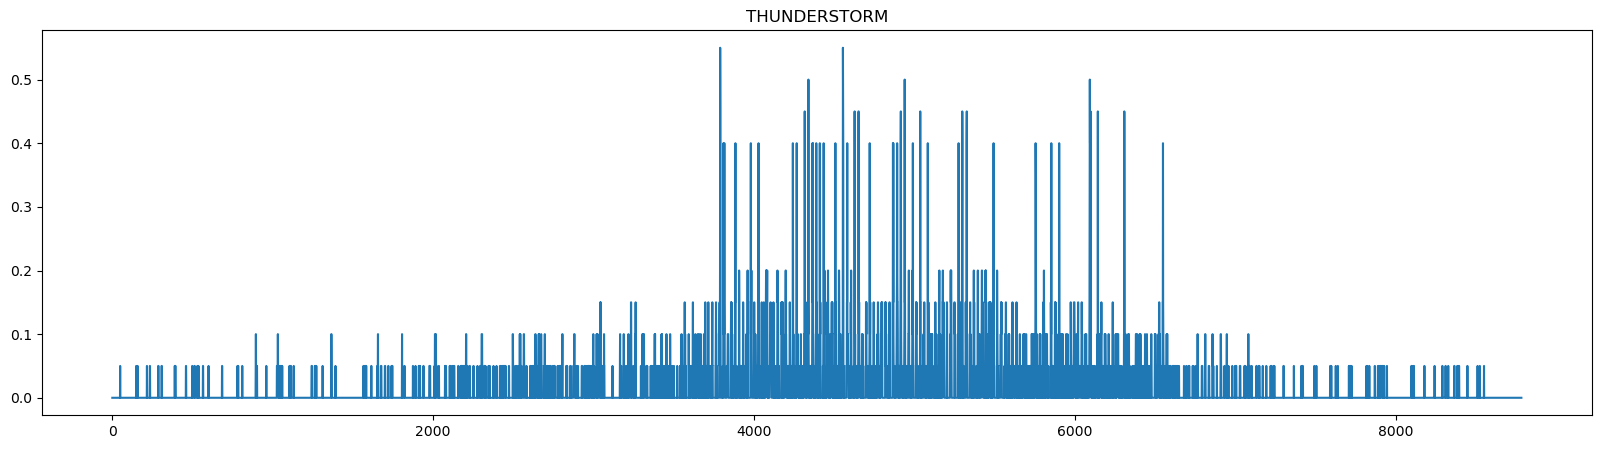

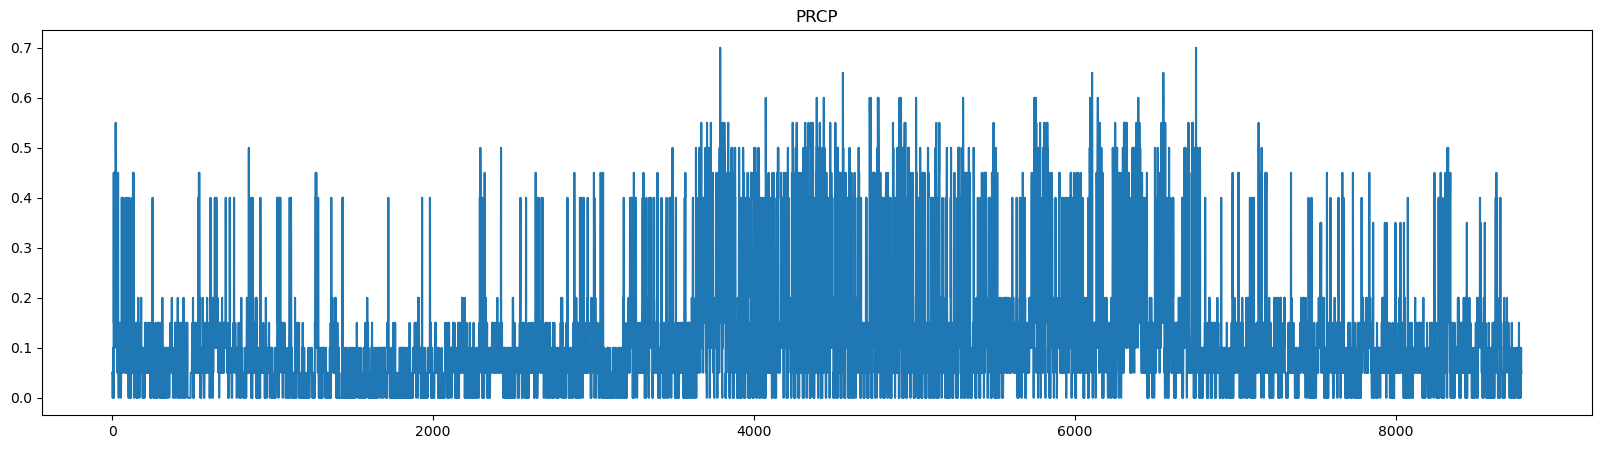

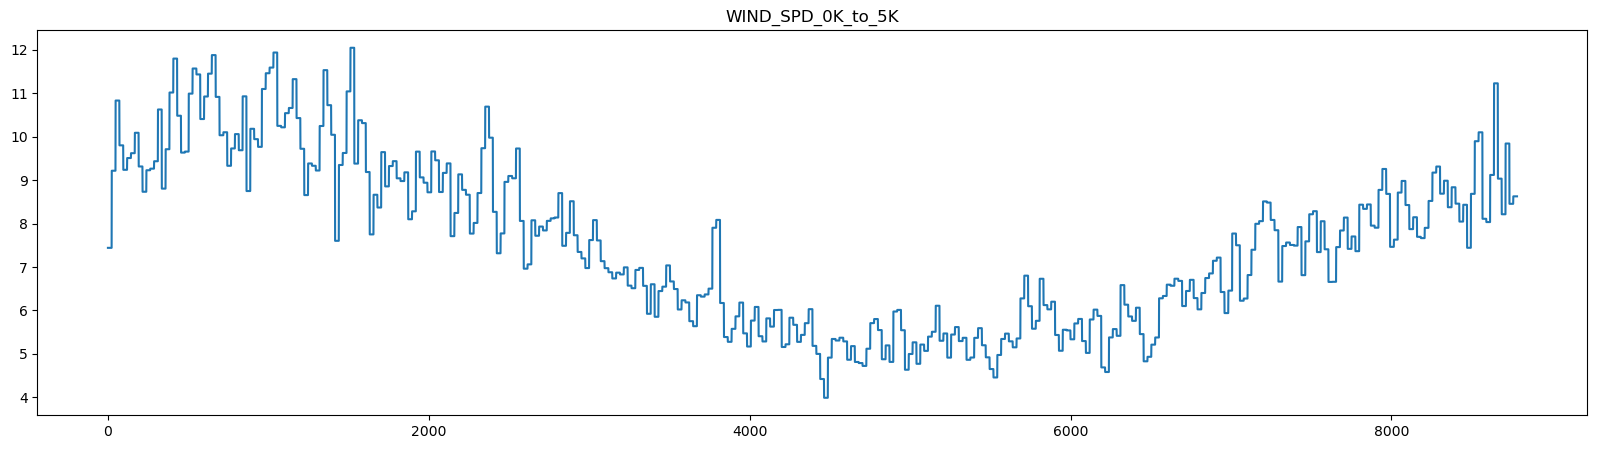

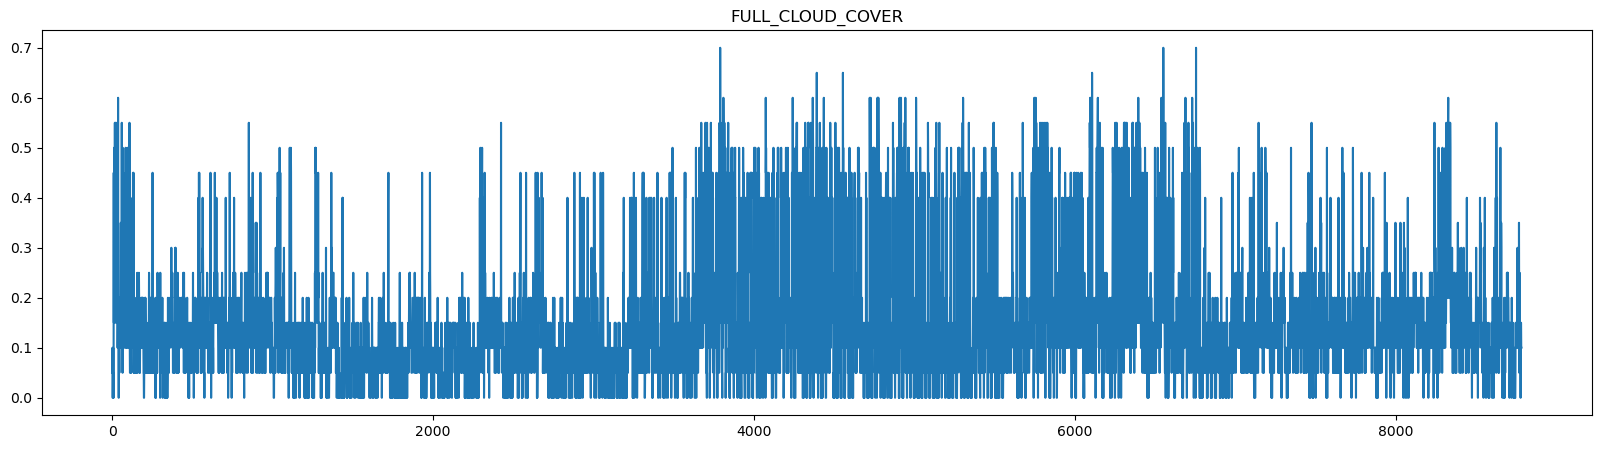

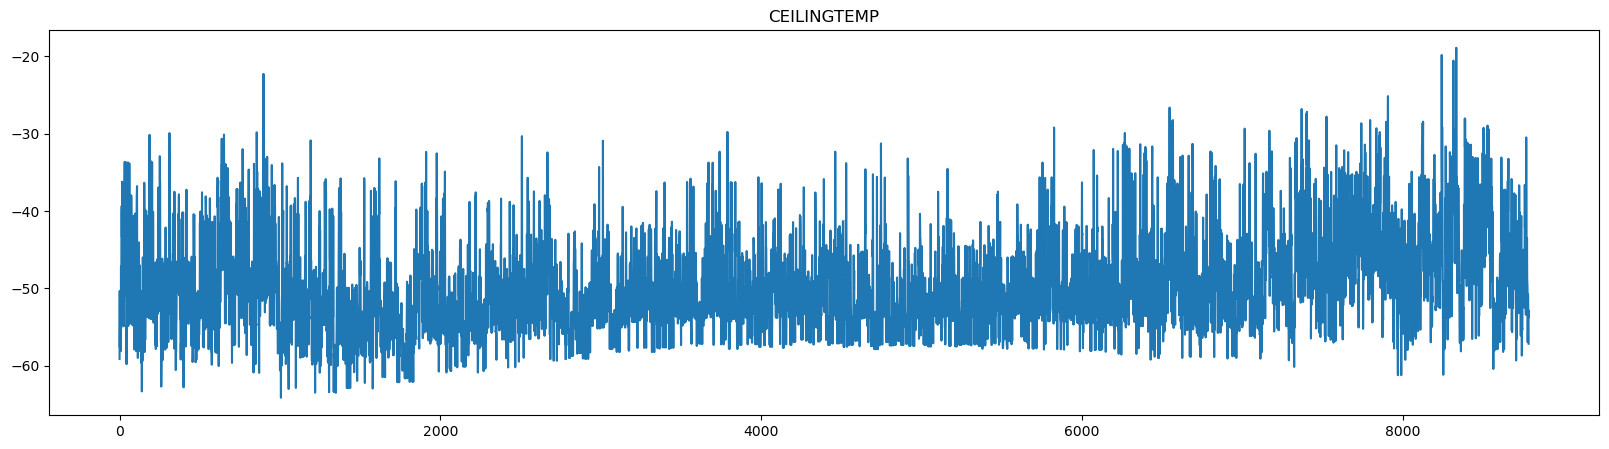

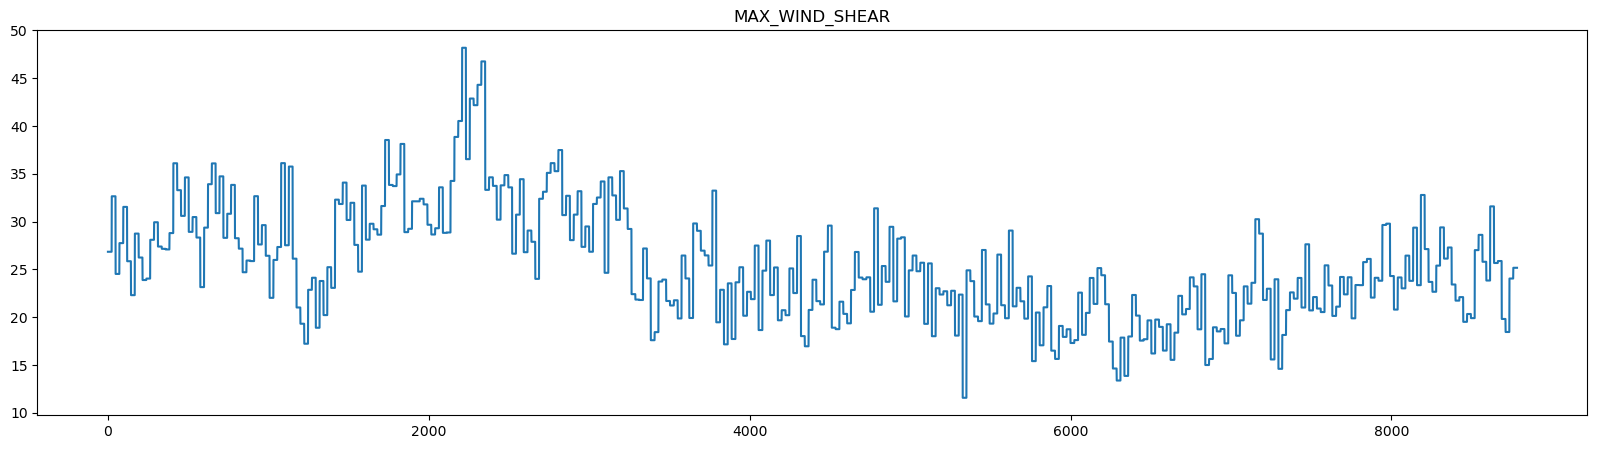

In [114]:
columns = [
'WINDSPEED',
'WINDGUSTSPEED',
'VISIBILITY',
'AIRTEMPERATURE',
'CLOUDCEILING',
'THUNDERSTORM',
'PRCP',
'WIND_SPD_0K_to_5K',
'FULL_CLOUD_COVER',
'CEILINGTEMP',
'MAX_WIND_SHEAR']

#values = combined_data.copy()

values = combined_data.groupby(['MONTH', 'DAY', 'HOUR']).agg({'WINDSPEED':'mean',
                                                              'WINDGUSTSPEED':'mean',
                                                              'VISIBILITY':'mean',
                                                              'AIRTEMPERATURE':'mean',
                                                              'CLOUDCEILING':'mean',
                                                              'THUNDERSTORM':'mean',
                                                              'PRCP':'mean',
                                                              'WIND_SPD_0K_to_5K':'mean',
                                                              'FULL_CLOUD_COVER':'mean',
                                                              'CEILINGTEMP':'mean',
                                                              'MAX_WIND_SHEAR':'mean'})



for col in columns:
    plt.figure(figsize=(20,5))
    plt.plot(range(len(values)), values[col])
    plt.title(col)
    plt.show()

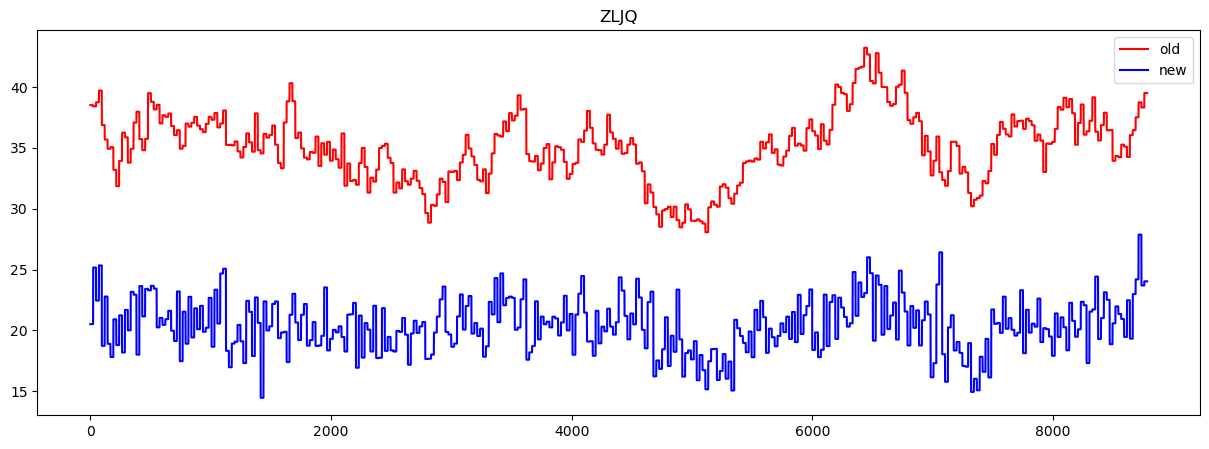

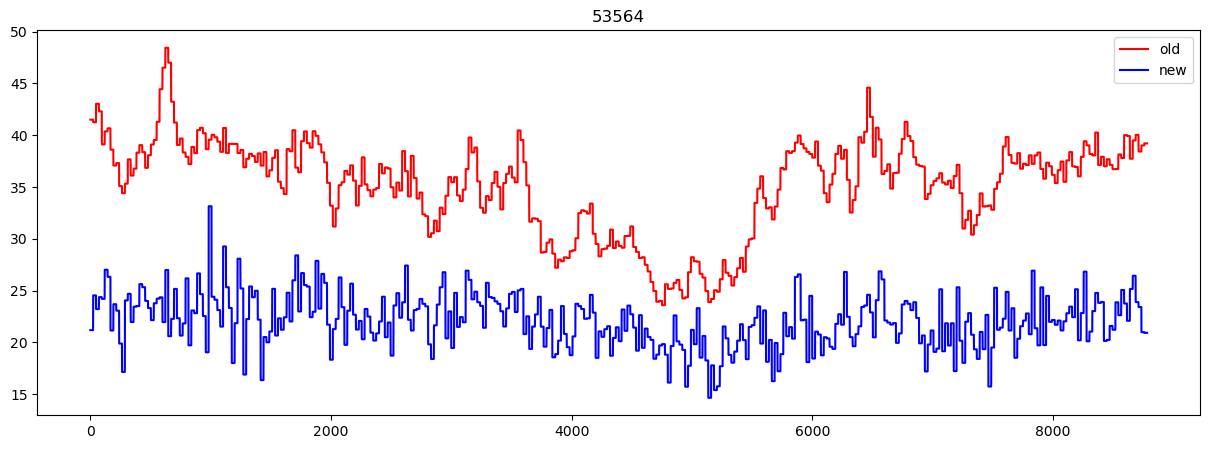

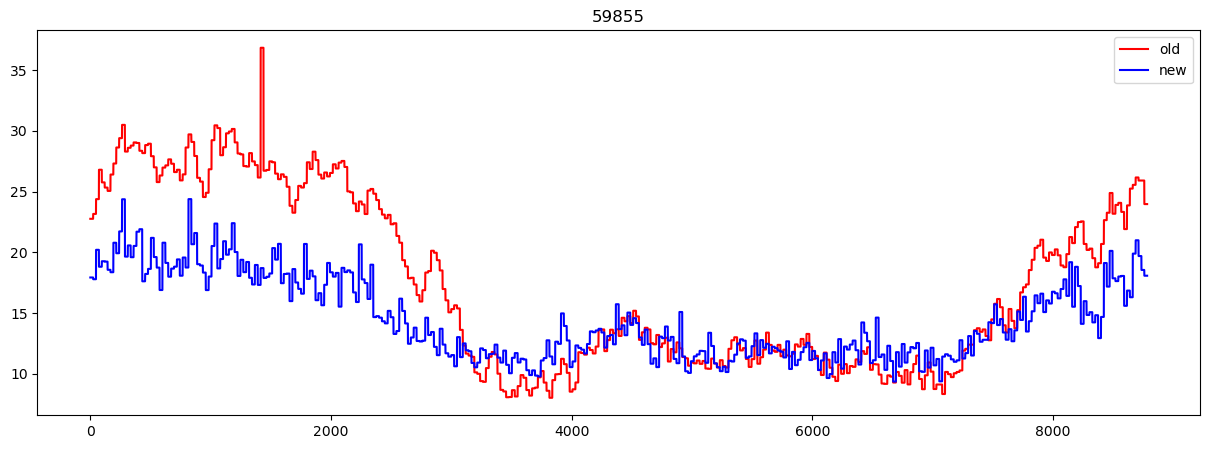

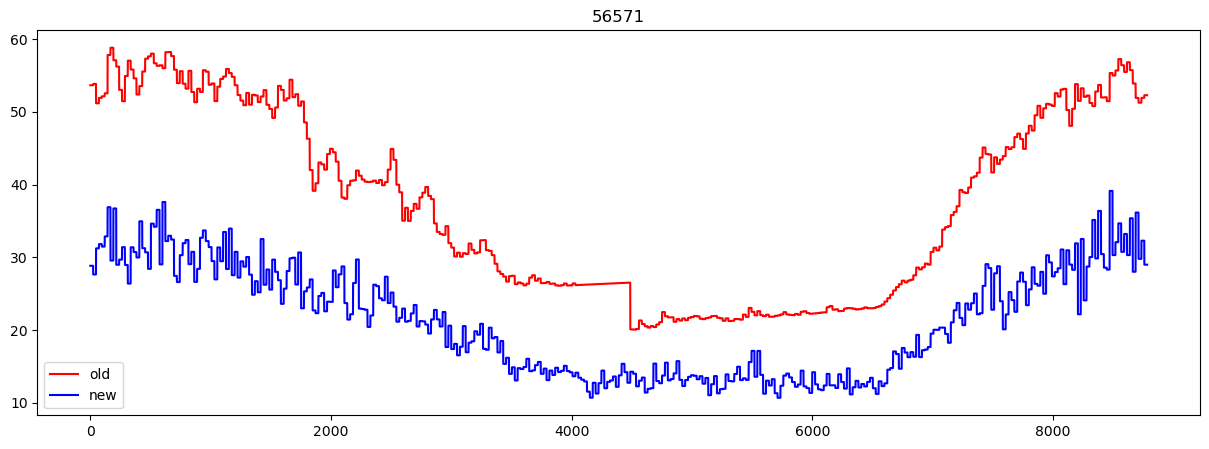

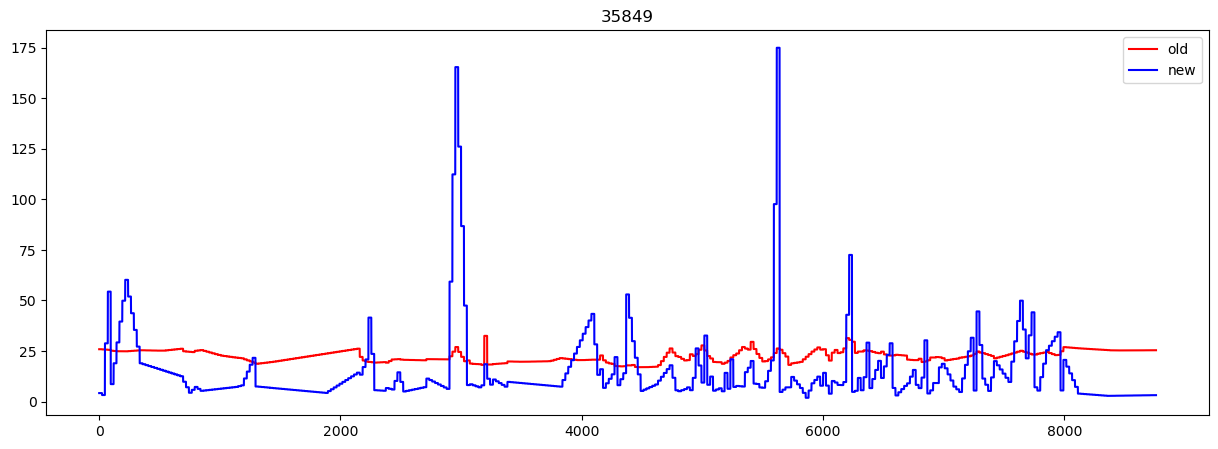

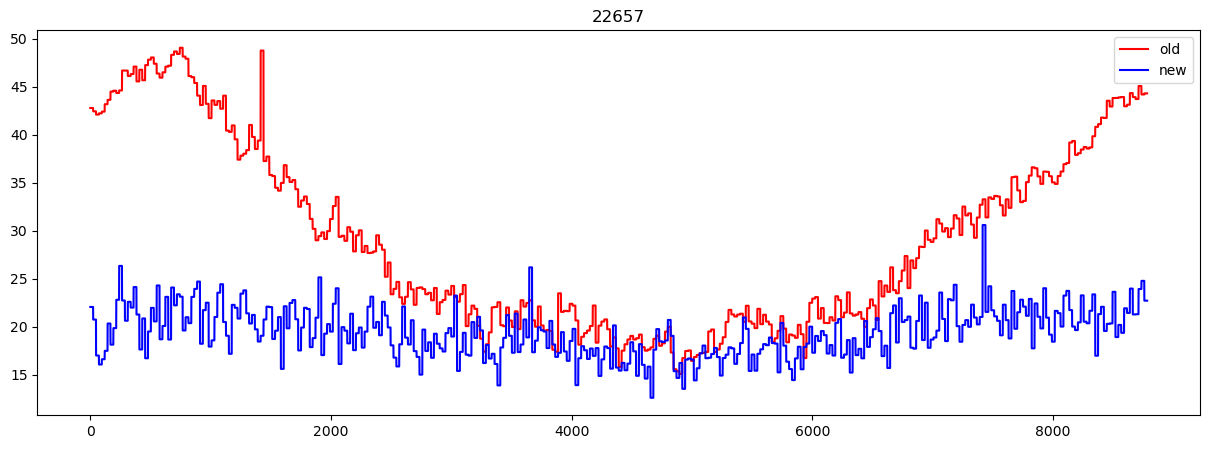

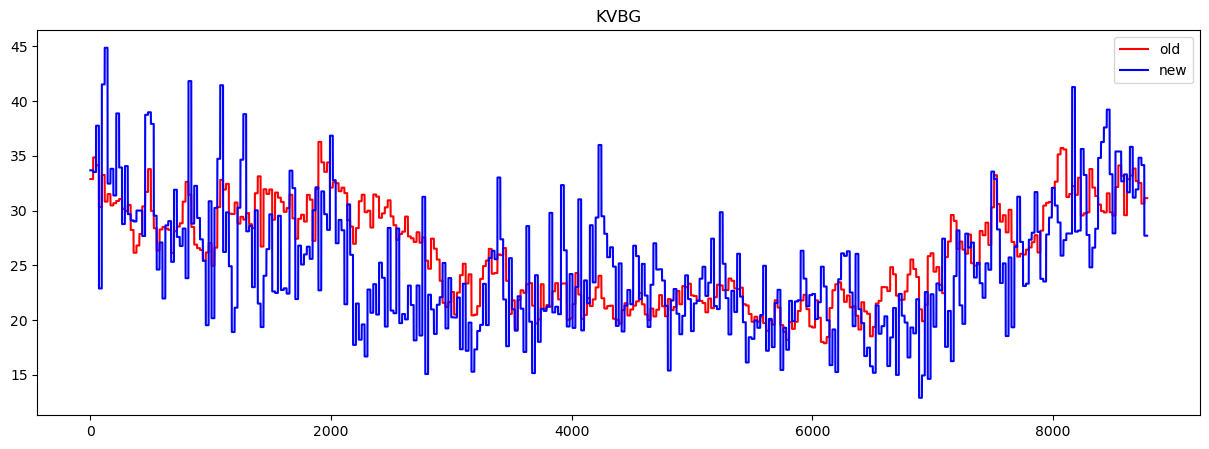

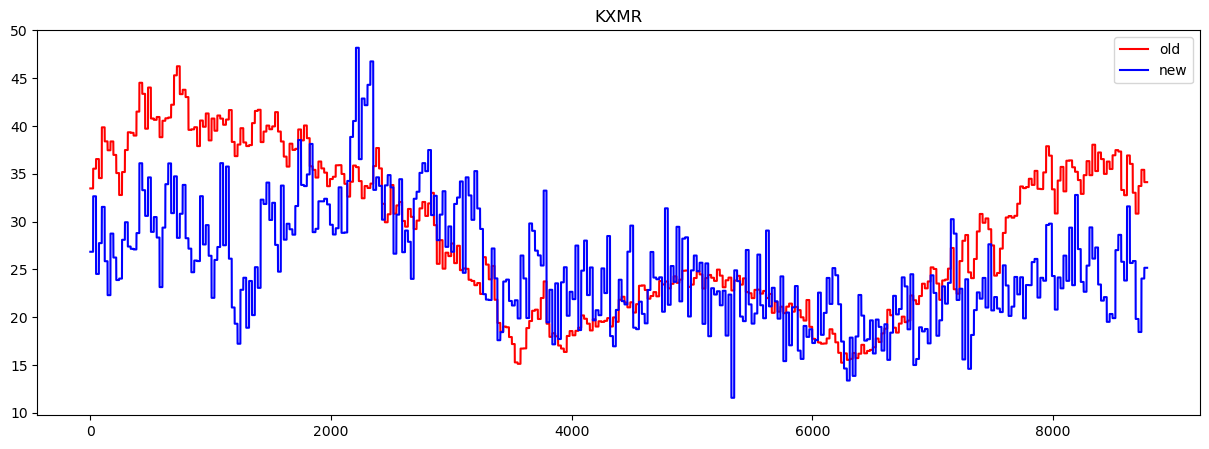

In [125]:
for key in list(location_info.keys()):

    original = pd.read_csv(f'data/preprocessed/{key}_weather.csv')
    original['MAX_WIND_SHEAR'] = original[['WIND_SPD_0K_to_5K',
                                           'WIND_SPD_5K_to_10K',
                                           'WIND_SPD_10K_to_15K',
                                           'WIND_SPD_15K_to_20K',
                                           'WIND_SPD_20K_to_25K',
                                           'WIND_SPD_25K_to_30K',
                                           'WIND_SPD_30K_to_35K',]].max(axis=1)
    
    new = pd.read_csv(f'data/preprocessed/{key}_weather_2.csv')
    
    original = original.groupby(['MONTH', 'DAY', 'HOUR']).agg({'MAX_WIND_SHEAR':'mean'})
    new = new.groupby(['MONTH', 'DAY', 'HOUR']).agg({'MAX_WIND_SHEAR':'mean'})
    
    plt.figure(figsize=(15,5))
    plt.title(key)
    plt.plot(range(len(original)), original['MAX_WIND_SHEAR'], c='r', label='old')
    plt.plot(range(len(new)), new['MAX_WIND_SHEAR'], c='b', label='new')
    plt.legend()
    plt.show()

In [ ]:
def process_air_data(key):
    folder = 'data/raw/upper_air/'
    file = f'{key}_UA.csv'
    location_name = location_info[key]['name']
    country = location_info[key]['country']
    country_type = location_info[key]['country_type']
    latitude = location_info[key]['latitude']
    longitude = location_info[key]['longitude']

    
    date_range = pd.date_range(start='2004-01-01', end='2023-12-31')
    date_df = pd.DataFrame(np.array(date_range).T, columns=['DATE'])
    date_df['YEAR'] = date_df['DATE'].dt.year
    date_df['MONTH'] = date_df['DATE'].dt.month
    date_df['DAY'] = date_df['DATE'].dt.day
    date_df.drop(['DATE'], axis=1, inplace=True)

    
    bins = [0, 5000, 10000, 15000, 20000, 25000, 30000, np.inf]
    bin_names = ['0K_to_5K', '5K_to_10K', '10K_to_15K', '15K_to_20K', '20K_to_25K', '25K_to_30K', '30K_to_35K']
    
    dfs = []
    
    for name in bin_names:
        new_df = date_df.copy()
        new_df['HGT'] = name
        dfs.append(new_df)
    
    date_df = pd.concat(dfs).reset_index(drop=True)
    
    data = pd.read_csv(folder+file)

    if "DATETIME" in data.columns:
        to_keep = ['DATETIME', 'HGT', 'TEMP_AIR', 'WIND_LVL_DIR', 'WIND_LVL_SPD']
        data = data[to_keep]
        data['DATE'] = pd.to_datetime(data['DATETIME'], format='%m/%d/%Y', errors='coerce')
    else:
        to_keep = ['YYYYMMDDHHmmss', 'HGT', 'TEMP_AIR', 'WIND_LVL_DIR', 'WIND_LVL_SPD']
        data = data[to_keep]
        data['DATETIME'] = data['YYYYMMDDHHmmss']
        data.drop('YYYYMMDDHHmmss', axis=1, inplace=True)
        data['DATE'] = pd.to_datetime(data['DATETIME'], format='%Y-%m-%d %H:%M:%S', errors='coerce')


    data.loc[data['DATE'].isna(), 'DATE'] = pd.to_datetime(data.loc[data['DATE'].isna(), 'DATETIME'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
    data = data.loc[data['DATE'].notna()]
    
    data['YEAR'] = data['DATE'].dt.year
    data['MONTH'] = data['DATE'].dt.month
    data['DAY'] = data['DATE'].dt.day

    data['HGT_BIN'] = np.clip(data['HGT'], 0, 40000)
    data['HGT_BIN'] = pd.cut(data['HGT'], bins, labels=bin_names)
    
    data = data.loc[data['HGT_BIN'].notna()]

    data.drop(['DATETIME', 'DATE', 'HGT'], axis=1, inplace=True)

    data = data[['HGT_BIN','YEAR','MONTH','DAY','TEMP_AIR','WIND_LVL_DIR','WIND_LVL_SPD']]
    data.columns = ['HGT','YEAR','MONTH','DAY','TEMP','WIND_DIR','WIND_SPD']
    
    data = pd.merge(date_df, data, on=['HGT', 'YEAR', 'MONTH', 'DAY'], how='left')
    
    data = data.groupby(['HGT', 'YEAR', 'MONTH', 'DAY'], observed=True).mean()
    data = data.reset_index(drop=False)

    data = data.sort_values(['HGT', 'YEAR', 'MONTH', 'DAY']).reset_index(drop=True)
    
    for hgt in data['HGT'].unique():
        for col in ['TEMP','WIND_DIR','WIND_SPD']:
            data.loc[data['HGT']==hgt, col] = data.loc[data['HGT']==hgt, col].interpolate(method='linear')
            data.loc[data['HGT']==hgt, col] = data.loc[data['HGT']==hgt].groupby(['HGT', 'MONTH', 'DAY'], observed=True)[col].transform(lambda x: x.fillna(x.mean()))
    
    data = data.sort_values(['YEAR', 'MONTH', 'DAY', 'HGT']).reset_index(drop=True)

    table = data.pivot_table(data, index=['YEAR', 'MONTH', 'DAY'],
                       columns='HGT', aggfunc="mean")

    new_col_names = []
    col_names = table.columns.values
    for col_name in col_names:
        first = col_name[0]
        second = col_name[1]

        new_col_names.append(f'{first}_{second}')

    table.columns = new_col_names
    table = table.reset_index(drop=False)

    table['LOCATION_KEY'] = key
    table['NAME'] = location_name
    table['COUNTRY'] = country
    table['COUNTRY_TYPE'] = country_type
    table['LATITUDE'] = latitude
    table['LONGITUDE'] = longitude
    table['LAT_LON'] = table['LATITUDE'].astype(str) + ',' + table['LONGITUDE'].astype(str)
    
    col_order = ['LOCATION_KEY',
                 'NAME',
                 'COUNTRY',
                 'COUNTRY_TYPE',
                 'LATITUDE',
                 'LONGITUDE',
                 'LAT_LON',
                 'YEAR',
                 'MONTH',
                 'DAY',
                 'TEMP_0K_to_5K',
                 'TEMP_5K_to_10K',
                 'TEMP_10K_to_15K',
                 'TEMP_15K_to_20K',
                 'TEMP_20K_to_25K',
                 'TEMP_25K_to_30K',
                 'TEMP_30K_to_35K',
                 'WIND_DIR_0K_to_5K',
                 'WIND_DIR_5K_to_10K',
                 'WIND_DIR_10K_to_15K',
                 'WIND_DIR_15K_to_20K',
                 'WIND_DIR_20K_to_25K',
                 'WIND_DIR_25K_to_30K',
                 'WIND_DIR_30K_to_35K',
                 'WIND_SPD_0K_to_5K',
                 'WIND_SPD_5K_to_10K',
                 'WIND_SPD_10K_to_15K',
                 'WIND_SPD_15K_to_20K',
                 'WIND_SPD_20K_to_25K',
                 'WIND_SPD_25K_to_30K',
                 'WIND_SPD_30K_to_35K',]

    for col in col_order[10:]:
        if col not in table.columns:
            table[col] = np.nan

    table = table[col_order]

    return table


def process_surface_data(key):
    folder = 'data/raw/surface/'
    file = f'{key}_SFC.csv'
    name = location_info[key]['name']
    country = location_info[key]['country']
    country_type = location_info[key]['country_type']
    latitude = location_info[key]['latitude']
    longitude = location_info[key]['longitude']
    
    to_keep = ['OBSERVATIONTIME',
               'WINDDIRECTION',
               'WINDSPEED',
               'WINDGUSTSPEED',
               'VISIBILITY',
               'AIRTEMPERATURE',
               'PRECIPAMOUNT1',
               'PRECIPCONDITION1',
               'PRECIPAMOUNT2',
               'PRECIPCONDITION2',
               'PRECIPAMOUNT3',
               'PRECIPCONDITION3',
               'PRECIPAMOUNT4',
               'PRECIPCONDITION4',
               'PRESENTMANUAL1',
               'PRESENTMANUAL2',
               'PRESENTMANUAL3',
               'PRESENTMANUAL4',
               'PRESENTMANUAL5',
               'PRESENTMANUAL6',
               'PRESENTMANUAL7',
               'PRESENTAUTOMATED1',
               'PRESENTAUTOMATED2',
               'PRESENTAUTOMATED3',
               'CLOUDCEILING',
               'CLOUDCOVER',
               'CLOUDBASEHEIGHT',]
    
    
    date_range = pd.date_range(start='2004-01-01 00:00:00', end='2023-12-31 23:00:00', freq='1h')
    date_df = pd.DataFrame(np.array(date_range).T, columns=['DATE'])
    date_df['YEAR'] = date_df['DATE'].dt.year
    date_df['MONTH'] = date_df['DATE'].dt.month
    date_df['DAY'] = date_df['DATE'].dt.day
    date_df['HOUR'] = date_df['DATE'].dt.hour
    date_df.drop(['DATE'], axis=1, inplace=True)

    
    data = pd.read_csv(folder + file)
    data = data[to_keep]
    
    data['DATETIME'] = pd.to_datetime(data['OBSERVATIONTIME'], format='%Y-%m-%d %H:%M:%S')
    data['YEAR'] = data['DATETIME'].dt.year
    data['MONTH'] = data['DATETIME'].dt.month
    data['DAY'] = data['DATETIME'].dt.day
    data['HOUR'] = data['DATETIME'].dt.hour
    
    data = data.loc[data['YEAR'].notna()]

    wx_cond_cols = ['THUNDERSTORM', 'FREEZERAIN', 'PRCP']
    
    man_nums = [[13, 17, 18, 19, 29, 80, 81, 82, 83, 84, 85, 86, 87, 88, 91, 92, 93, 94, 95, 96, 97, 98, 99],
                [24, 27, 56, 57, 66, 67, 76, 77, 78, 79, 89, 90, 96, 99],
                [13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 27, 29, 36, 37, 38, 39, 50, 51, 52, 53, 54,
                 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78,
                 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99],]
    
    auto_nums = [[12, 18, 26, 90, 91, 92, 93, 94, 95, 96, 99],
                 [11, 25, 47, 48, 54, 55, 56, 64, 65, 66, 74, 75, 76, 77, 78, 89, 93, 96],
                 [11, 12, 18, 21, 22, 23, 24, 25, 26, 27, 40, 41, 42, 43, 44, 45, 46, 47, 48, 50, 51, 52, 53, 54,
                  55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 70, 71, 72, 73, 74, 75, 76, 77, 78, 80,
                  81, 82, 83, 84, 85, 86, 87, 89, 90, 91, 92, 93, 94, 95, 96],]

    for i in range(len(wx_cond_cols)):
        wx_cond = wx_cond_cols[i]
        man_num = man_nums[i]
        auto_num = auto_nums[i]

        data[wx_cond] = 0
        
        for x in range(1,8):
            col = f'PRESENTMANUAL{x}'
            data.loc[data[col].isin(man_num), wx_cond] = 1
    
        for x in range(1,4):
            col = f'PRESENTAUTOMATED{x}'
            data.loc[data[col].isin(auto_num), wx_cond] = 1



    data['CLOUDCOVER'].fillna(0, inplace=True)
    data['WINDSPEED'].fillna(0, inplace=True)
    data['WINDGUSTSPEED'].fillna(0, inplace=True)


    data['PRECIPAMOUNT1'].fillna(0, inplace=True)
    data['PRECIPAMOUNT'] = data['PRECIPAMOUNT1']

    data.loc[data['PRECIPAMOUNT'] > 0.01, 'PRCP'] = 1

    data['VISIBILITY'].fillna(30000, inplace=True)
    data['CLOUDBASEHEIGHT'].fillna(70000, inplace=True)
    data['CLOUDCEILING'].fillna(70000, inplace=True)

    data = data.drop(['OBSERVATIONTIME', 'DATETIME',
                      'PRESENTMANUAL1', 'PRESENTMANUAL2', 'PRESENTMANUAL3', 'PRESENTMANUAL4', 'PRESENTMANUAL5', 'PRESENTMANUAL6', 'PRESENTMANUAL7',
                      'PRESENTAUTOMATED1', 'PRESENTAUTOMATED2', 'PRESENTAUTOMATED3',
                      'PRECIPAMOUNT1', 'PRECIPAMOUNT2', 'PRECIPAMOUNT3', 'PRECIPAMOUNT4', 'PRECIPCONDITION1', 'PRECIPCONDITION2', 'PRECIPCONDITION3', 'PRECIPCONDITION4', ], axis=1)
    
    data = data.groupby(['YEAR', 'MONTH', 'DAY', 'HOUR']).agg({'WINDDIRECTION':'mean',
                                                               'WINDSPEED':'max',
                                                               'WINDGUSTSPEED':'max',
                                                               'VISIBILITY':'min',
                                                               'AIRTEMPERATURE':'mean',
                                                               'CLOUDCEILING':'min',
                                                               'CLOUDCOVER':'mean',
                                                               'CLOUDBASEHEIGHT':'min',
                                                               'THUNDERSTORM':'max',
                                                               'FREEZERAIN':'max',
                                                               'PRCP':'max',
                                                               'PRECIPAMOUNT':'max'})

    data = data.sort_values(['YEAR', 'MONTH', 'DAY', 'HOUR']).reset_index(drop=False)

    data = pd.merge(date_df, data, on=['YEAR', 'MONTH', 'DAY', 'HOUR'], how='left')

    to_fix = ['WINDDIRECTION',
            'WINDSPEED',
            'WINDGUSTSPEED',
            'VISIBILITY',
            'AIRTEMPERATURE',
            'THUNDERSTORM',
            'FREEZERAIN',
            'PRCP',]

    for col in to_fix:
        data[col] = data.groupby(['MONTH', 'DAY', 'HOUR'], observed=True)[col].transform(lambda x: x.fillna(x.mean()))
        data[col] = data.groupby(['YEAR', 'MONTH', 'DAY'], observed=True)[col].transform(lambda x: x.fillna(x.mean()))
        
    
    data.loc[data['THUNDERSTORM'] >= .25, 'THUNDERSTORM'] = 1
    data.loc[data['THUNDERSTORM'] != 1, 'THUNDERSTORM'] = 0

    data.loc[data['FREEZERAIN'] >= .25, 'FREEZERAIN'] = 1
    data.loc[data['FREEZERAIN'] != 1, 'FREEZERAIN'] = 0

    data.loc[data['PRCP'] >= .25, 'PRCP'] = 1
    data.loc[data['PRCP'] != 1, 'PRCP'] = 0

    data.loc[(data['CLOUDCOVER'].isna()) & (data['PRCP']==1), 'CLOUDCOVER'] = 8
    data['CLOUDCOVER'] = data.groupby(['MONTH', 'DAY', 'HOUR'], observed=True)['CLOUDCOVER'].transform(lambda x: x.fillna(x.mean()))
    data['CLOUDCOVER'] = data.groupby(['YEAR', 'MONTH', 'DAY'], observed=True)['CLOUDCOVER'].transform(lambda x: x.fillna(x.mean()))
    data['CLOUDCOVER'].fillna(0, inplace=True)
    
    data.loc[(data['CLOUDCEILING'].isna()) & (data['PRCP']==1), 'CLOUDCEILING'] = data.loc[(data['CLOUDCEILING'].isna()) & (data['PRCP']==1)].groupby(['MONTH', 'PRCP'], observed=True)['CLOUDCEILING'].transform(lambda x: x.fillna(x.mean()))
    data['CLOUDCEILING'] = data.groupby(['MONTH', 'DAY', 'HOUR'], observed=True)['CLOUDCEILING'].transform(lambda x: x.fillna(x.mean()))
    data['CLOUDCEILING'] = data.groupby(['YEAR', 'MONTH', 'DAY'], observed=True)['CLOUDCEILING'].transform(lambda x: x.fillna(x.mean()))
    data['CLOUDCEILING'].fillna(70000, inplace=True)
    
    data.loc[(data['CLOUDBASEHEIGHT'].isna()) & (data['PRCP']==1), 'CLOUDBASEHEIGHT'] = data.loc[(data['CLOUDBASEHEIGHT'].isna()) & (data['PRCP']==1)].groupby(['MONTH', 'PRCP'], observed=True)['CLOUDBASEHEIGHT'].transform(lambda x: x.fillna(x.mean()))
    data['CLOUDBASEHEIGHT'] = data.groupby(['MONTH', 'DAY', 'HOUR'], observed=True)['CLOUDBASEHEIGHT'].transform(lambda x: x.fillna(x.mean()))
    data['CLOUDBASEHEIGHT'] = data.groupby(['YEAR', 'MONTH', 'DAY'], observed=True)['CLOUDBASEHEIGHT'].transform(lambda x: x.fillna(x.mean()))
    data['CLOUDBASEHEIGHT'].fillna(70000, inplace=True)
    
    data.loc[(data['PRECIPAMOUNT'].isna()) & (data['PRCP']==1), 'PRECIPAMOUNT'] = data.loc[(data['PRECIPAMOUNT'].isna()) & (data['PRCP']==1)].groupby(['MONTH', 'PRCP'], observed=True)['PRECIPAMOUNT'].transform(lambda x: x.fillna(x.mean()))
    data['PRECIPAMOUNT'] = data.groupby(['MONTH', 'DAY', 'HOUR'], observed=True)['PRECIPAMOUNT'].transform(lambda x: x.fillna(x.mean()))
    data['PRECIPAMOUNT'] = data.groupby(['YEAR', 'MONTH', 'DAY'], observed=True)['PRECIPAMOUNT'].transform(lambda x: x.fillna(x.mean()))
    data['PRECIPAMOUNT'].fillna(0, inplace=True)

    data.loc[(data['PRCP']==1), 'CLOUDCOVER'] = 8
    data.loc[(data['PRCP']==1), 'CLOUDCEILING'] = np.clip(data.loc[(data['PRCP']==1), 'CLOUDCEILING'], 0, 30000)
    data.loc[(data['PRCP']==1), 'CLOUDBASEHEIGHT'] = np.clip(data.loc[(data['PRCP']==1), 'CLOUDBASEHEIGHT'], 0, 30000)

    data['CLOUDCOND'] = 'CLR'
    data.loc[(data['CLOUDCOVER'] >= 1) & (data['CLOUDCOVER'] <= 2), 'CLOUDCOND'] = 'FEW'
    data.loc[(data['CLOUDCOVER'] >= 3) & (data['CLOUDCOVER'] <= 4), 'CLOUDCOND'] = 'SCT'
    data.loc[(data['CLOUDCOVER'] >= 5) & (data['CLOUDCOVER'] <= 7), 'CLOUDCOND'] = 'BKN'
    data.loc[(data['CLOUDCOVER'] >= 8), 'CLOUDCOND'] = 'OVC'

    data.loc[data['CLOUDCOND'].isin(['BKN','OVC']), 'CLOUDCEILING'] = np.clip(data.loc[data['CLOUDCOND'].isin(['BKN','OVC']), 'CLOUDCEILING'], 0, 40000)
    data.loc[data['CLOUDCOND'].isin(['BKN','OVC']), 'CLOUDBASEHEIGHT'] = np.clip(data.loc[data['CLOUDCOND'].isin(['BKN','OVC']), 'CLOUDBASEHEIGHT'], 0, 40000)

    data['LOCATION_KEY'] = key
    data['NAME'] = name
    data['COUNTRY'] = country
    data['COUNTRY_TYPE'] = country_type
    data['LATITUDE'] = latitude
    data['LONGITUDE'] = longitude
    data['LAT_LON'] = data['LATITUDE'].astype(str) + ',' + data['LONGITUDE'].astype(str)
    
    data['WEATHER_KEY'] = data['LOCATION_KEY'] + '_' + data['YEAR'].astype(str) + '_' + data['MONTH'].astype(str) + '_' + data['DAY'].astype(str) + '_' + data['HOUR'].astype(str)

    col_order = ['WEATHER_KEY',
                 'LOCATION_KEY',
                 'NAME',
                 'COUNTRY',
                 'COUNTRY_TYPE',
                 'LATITUDE',
                 'LONGITUDE',
                 'LAT_LON',
                 'YEAR',
                 'MONTH',
                 'DAY',
                 'HOUR',
                 'WINDDIRECTION',
                 'WINDSPEED',
                 'WINDGUSTSPEED',
                 'VISIBILITY',
                 'AIRTEMPERATURE',
                 'CLOUDCEILING',
                 'CLOUDCOVER',
                 'CLOUDBASEHEIGHT',
                 'CLOUDCOND',
                 'THUNDERSTORM',
                 'FREEZERAIN',
                 'PRCP',
                 'PRECIPAMOUNT',]

    data = data[col_order]

    return data

def calculate_upper_air_conditions(data):
    wind_cols = ['0K_to_5K', '5K_to_10K', '10K_to_15K', '15K_to_20K', '20K_to_25K', '25K_to_30K', '30K_to_35K']
    
    for y in range(len(wind_cols)-1):
        top_col = wind_cols[y+1]
        bottom_col = wind_cols[y]
    
        mag_top = data['WIND_SPD_'+top_col]
        mag_bottom = data['WIND_SPD_'+bottom_col]
    
        angle_top = np.radians(data['WIND_DIR_'+top_col])
        angle_bottom = np.radians(data['WIND_DIR_'+bottom_col])
        
        wind_top_x = mag_top * np.cos(angle_top)
        wind_top_y = mag_top * np.sin(angle_top)
    
        wind_bottom_x = mag_bottom * np.cos(angle_bottom)
        wind_bottom_y = mag_bottom * np.sin(angle_bottom)
    
        change_x = wind_top_x - wind_bottom_x
        change_y = wind_top_y - wind_bottom_y
    
        shear = np.sqrt(change_x**2 + change_y**2)
    
        data['WIND_SHEAR_'+top_col] = shear
    
    
    data['FULL_CLOUD_COVER'] = 0
    data.loc[data['CLOUDCOND'].isin(['BKN', 'OVC']), 'FULL_CLOUD_COVER'] = 1
    
    bins = [0, 5000, 10000, 15000, 20000, 25000, 30000, np.inf]
    bin_names = ['0K_to_5K', '5K_to_10K', '10K_to_15K', '15K_to_20K', '20K_to_25K', '25K_to_30K', '30K_to_35K']
    
    data['CLOUD_HEIGHT'] = pd.cut(data['CLOUDCEILING'], bins, labels=bin_names)
    data['CLOUD_HEIGHT'].fillna('30K_to_35K', inplace=True)
    
    values = []
    
    heights = data.loc[data['CLOUD_HEIGHT'].notna(), 'CLOUD_HEIGHT'].values
    indexes = data.loc[data['CLOUD_HEIGHT'].notna(), 'CLOUD_HEIGHT'].index.values
    
    data['CEILINGTEMP'] = np.nan
    for idx, height in zip(indexes, heights):
        data.loc[idx, 'CEILINGTEMP'] = data.loc[idx, 'TEMP_'+height]

    data['CEILINGTEMP'].fillna(20, inplace=True)
    
    return data